# Regression in Matrix Form

> *Adapted from teaching notebooks contributed by **Lei Qian**, who developed the regression
> material for this course.*

**This notebook is self-contained; it recaps least squares before generalizing it.**

The previous notebook solved the normal equations for a line with **one** feature. Real problems have
many — a house price depends on size, age, quality, and dozens more. Writing a separate equation for
each parameter quickly becomes unmanageable.

Matrix notation fixes that. The whole problem, for any number of features, collapses to one equation
— and it turns out to be the **pseudo-inverse** built in Unit 2 §2.5, now doing the job it was built
for.

## Learning objectives

- Write a regression model as $\mathbf{y} = X\mathbf{b}$ using a **design matrix**.
- Derive the **normal equations** $X^{\top}X\mathbf{b} = X^{\top}\mathbf{y}$ by setting the partial
  derivatives to zero.
- Recognize $\mathbf{b} = (X^{\top}X)^{-1}X^{\top}\mathbf{y}$ as the **pseudo-inverse** from §2.5.

## Background

Stack the observations. With $m$ features and $n$ observations, build the **design matrix** $X$: one
row per observation, one column per feature, plus a leading column of **ones** to carry the intercept.

$$X = \begin{bmatrix} 1 & x_{11} & \cdots & x_{1m}\\ 1 & x_{21} & \cdots & x_{2m}\\ \vdots & & & \vdots\\ 1 & x_{n1} & \cdots & x_{nm} \end{bmatrix}, \qquad \mathbf{b} = \begin{bmatrix} b_0 \\ b_1 \\ \vdots \\ b_m \end{bmatrix}$$

Then all $n$ predictions at once are just $\hat{\mathbf{y}} = X\mathbf{b}$, and the loss is the squared
length of the residual vector:

$$S(\mathbf{b}) = \mathbf{e}^{\top}\mathbf{e}, \qquad \mathbf{e} = \mathbf{y} - X\mathbf{b}$$

Setting every partial derivative $\partial S/\partial b_j$ to zero gives the **normal equations**:

$$X^{\top}X\,\mathbf{b} = X^{\top}\mathbf{y} \quad\Longrightarrow\quad \mathbf{b} = (X^{\top}X)^{-1}X^{\top}\mathbf{y} = X^{+}\mathbf{y}$$

That $X^{+} = (X^{\top}X)^{-1}X^{\top}$ is exactly the **Moore–Penrose pseudo-inverse** from
`U2-5_Determinants-3_PseudoInverseAndLeastSquares`. $X$ itself is tall and has no inverse; $X^{\top}X$ is square and does.

**Prerequisite pointer:** §2.5-3 derived $X^{+}$ geometrically. This notebook re-derives it from the
loss, so it stands alone either way.

## This notebook covers

1. The design matrix.
2. The loss in matrix form.
3. Deriving the normal equations.
4. Solving them, and checking against `U3-7_Regression-3_ThreeWays`.
5. Several features at once.

**Prerequisites:** `U3-7_Regression-1_FittingALine`, `U2-5_Determinants-3_PseudoInverseAndLeastSquares`

**Dataset:** `mlr01.csv` — a small multi-feature table from the shared dataset library.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers
# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

## 1. The design matrix

Start with the one-feature case so the notation can be checked against something familiar. Five
observations of $(x, y)$; the design matrix gets a column of ones and a column of $x$ values.

The column of ones is the trick that lets the intercept be treated as just another parameter: the
first entry of $X\mathbf{b}$ is $1 \cdot b_0 + x_1 b_1$, which is the line's formula.

In [2]:
x = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
y = np.array([2.1, 4.2, 5.8, 8.1, 9.9])

X = np.column_stack([np.ones(len(x)), x])       # the ones column carries the intercept
helpers.show(X, name="X")
helpers.show(y, name=r"\mathbf{y}")
print(f"X is {X.shape}: {X.shape[0]} observations, {X.shape[1]} parameters (intercept + slope)")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

X is (5, 2): 5 observations, 2 parameters (intercept + slope)


In [3]:
# a guess at the parameters, to see what X b computes
b_guess = np.array([0.5, 2.0])
helpers.show(b_guess, name=r"\mathbf{b}")
helpers.show(X @ b_guess, name=r"X\mathbf{b}")
print("each entry is  b0 + b1 * x_i  -- all n predictions in one product")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

each entry is  b0 + b1 * x_i  -- all n predictions in one product


## 2. The loss, in matrix form

The residual vector is $\mathbf{e} = \mathbf{y} - X\mathbf{b}$, and the sum of squared residuals is
its dot product with itself:

$$S(\mathbf{b}) = \mathbf{e}^{\top}\mathbf{e} = \sum_i e_i^2$$

That is the row-times-column form from §2.2 — a row vector meeting a column vector to give one number.
Same quantity as before, written compactly.

In [4]:
e = y - X @ b_guess
helpers.show(e, name=r"\mathbf{e}")

S_matrix = e @ e                      # e^T e
S_loop = sum(ei**2 for ei in e)       # the same thing, elementwise
print(f"S = e^T e        = {S_matrix:.6f}")
print(f"S = sum of e_i^2 = {S_loop:.6f}")
print("\nsame number -- the matrix form is just compact notation")

<IPython.core.display.Math object>

S = e^T e        = 1.260000
S = sum of e_i^2 = 1.260000

same number -- the matrix form is just compact notation


## 3. Deriving the normal equations

Expand the loss:

$$S(\mathbf{b}) = (\mathbf{y} - X\mathbf{b})^{\top}(\mathbf{y} - X\mathbf{b})
= \mathbf{y}^{\top}\mathbf{y} - 2\mathbf{b}^{\top}X^{\top}\mathbf{y} + \mathbf{b}^{\top}X^{\top}X\mathbf{b}$$

Now minimize. From §3.5, a minimum needs every partial derivative to vanish — and from §3.6, those
partials collected together are the gradient. Differentiating with respect to $\mathbf{b}$:

$$\frac{\partial S}{\partial \mathbf{b}} = -2X^{\top}\mathbf{y} + 2X^{\top}X\mathbf{b} = \mathbf{0}$$

Rearranging gives the **normal equations**:

$$\boxed{X^{\top}X\,\mathbf{b} = X^{\top}\mathbf{y}}$$

$X^{\top}X$ is square — $(m{+}1) \times (m{+}1)$, however tall $X$ is — so this is an ordinary linear
system of exactly the kind Unit 2 solved.

In [5]:
XtX = X.T @ X
Xty = X.T @ y

helpers.show(XtX, name=r"X^\top X")
helpers.show(Xty, name=r"X^\top \mathbf{y}")
print(f"X is {X.shape} (tall, no inverse), but X^T X is {XtX.shape} (square)")
print(f"det(X^T X) = {np.linalg.det(XtX):.4f}  -> invertible, so there is a unique solution")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

X is (5, 2) (tall, no inverse), but X^T X is (2, 2) (square)
det(X^T X) = 50.0000  -> invertible, so there is a unique solution


In [6]:
helpers.show_aug(XtX, Xty, label="the normal equations")

b = np.linalg.solve(XtX, Xty)
helpers.show(b, name=r"\mathbf{b}")
print(f"intercept b0 = {b[0]:.6f}")
print(f"slope     b1 = {b[1]:.6f}")

# and via the pseudo-inverse, which is the same thing written differently
X_plus = np.linalg.inv(XtX) @ X.T
helpers.show(np.round(X_plus @ y, 6), label="X^+ y, the pseudo-inverse route")
print(f"\nnumpy's pinv agrees: {np.allclose(X_plus, np.linalg.pinv(X))}")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

intercept b0 = 0.170000
slope     b1 = 1.950000


<IPython.core.display.Math object>


numpy's pinv agrees: True


## 4. The same answer as the scalar formulas

This had better reproduce the closed forms of `U3-7_Regression-1_FittingALine`, which came from the
same minimization written out one
symbol at a time. It does — and that equivalence is worth stating explicitly:

$$b_1 = \frac{s_{xy}}{s_{xx}} \quad\text{is exactly the one-feature case of}\quad \mathbf{b} = X^{+}\mathbf{y}$$

Two languages, one answer. The statistics course writes it the first way; the linear algebra course
writes it the second.

In [7]:
x_bar, y_bar = x.mean(), y.mean()
b1_scalar = np.sum((x - x_bar)*(y - y_bar)) / np.sum((x - x_bar)**2)
b0_scalar = y_bar - b1_scalar*x_bar

print(f"{'method':<34} {'intercept':>12} {'slope':>12}")
print("-" * 60)
print(f"{'scalar formulas (Regression-1)':<34} {b0_scalar:12.6f} {b1_scalar:12.6f}")
print(f"{'normal equations, matrix form':<34} {b[0]:12.6f} {b[1]:12.6f}")
print(f"{'pseudo-inverse X+ y':<34} {(X_plus @ y)[0]:12.6f} {(X_plus @ y)[1]:12.6f}")

method                                intercept        slope
------------------------------------------------------------
scalar formulas (Regression-1)         0.170000     1.950000
normal equations, matrix form          0.170000     1.950000
pseudo-inverse X+ y                    0.170000     1.950000


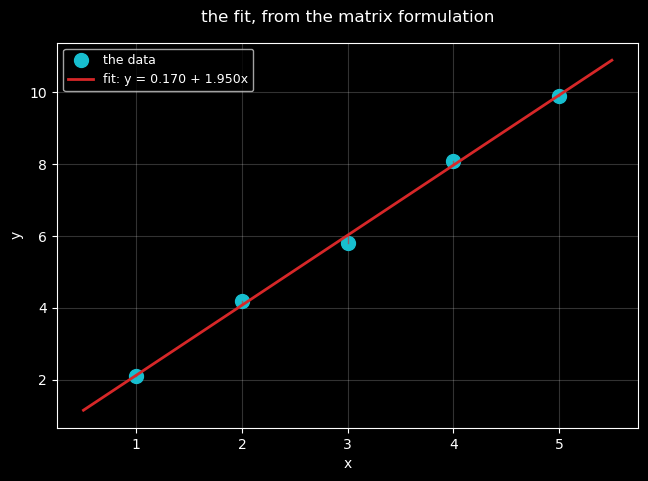

In [8]:
grid = np.linspace(0.5, 5.5, 50)
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(x, y, "o", color="tab:cyan", markersize=10, label="the data")
ax.plot(grid, b[0] + b[1]*grid, color="tab:red", lw=2,
        label=f"fit: y = {b[0]:.3f} + {b[1]:.3f}x")
for xi, yi in zip(x, y):
    ax.plot([xi, xi], [yi, b[0] + b[1]*xi], "-", color="tab:red", lw=1, alpha=0.6)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.legend(fontsize=9); ax.grid(alpha=0.2)
ax.set_title("the fit, from the matrix formulation", pad=15)
plt.show()

## 5. Why bother: several features at once

Here is the payoff. Nothing above assumed one feature — add columns to $X$ and **the same single
equation** solves it. Below, a small table with three predictors and one response.

Writing this out as scalar formulas would take four coupled equations. In matrix form it is the
identical line of code.

In [9]:
mlr = pd.read_csv(helpers.data('MSDS 520 Calculus/mlr01.csv'))
print(f"{len(mlr)} observations, columns: {list(mlr.columns)}")
mlr

8 observations, columns: ['X1', 'X2', 'X3', 'X4']


,X1,X2,X3,X4
0,2.9,9.2,13.2,2
1,2.4,8.7,11.5,3
2,2.0,7.2,10.8,4
3,2.3,8.5,12.3,2
4,3.2,9.6,12.6,3
5,1.9,6.8,10.6,5
6,3.4,9.7,14.1,1
7,2.1,7.9,11.2,3


In [10]:
# X1 is the response; X2, X3, X4 are the predictors
y_multi = mlr['X1'].values
features = mlr[['X2', 'X3', 'X4']].values

X_multi = np.column_stack([np.ones(len(y_multi)), features])
helpers.show(X_multi, name="X")
print(f"X is {X_multi.shape}: {X_multi.shape[0]} observations, {X_multi.shape[1]} parameters")
print(f"X^T X is {(X_multi.T @ X_multi).shape} -- still square, still solvable")

<IPython.core.display.Math object>

X is (8, 4): 8 observations, 4 parameters
X^T X is (4, 4) -- still square, still solvable


In [11]:
b_multi = np.linalg.solve(X_multi.T @ X_multi, X_multi.T @ y_multi)
helpers.show(np.round(b_multi, 5), name=r"\mathbf{b}")

names = ['intercept', 'X2', 'X3', 'X4']
for nm, coef in zip(names, b_multi):
    print(f"  {nm:<10} {coef:+12.5f}")

# check against sklearn
from sklearn.linear_model import LinearRegression
sk = LinearRegression().fit(features, y_multi)
print(f"\nsklearn intercept {sk.intercept_:+.5f}, coefficients {np.round(sk.coef_, 5)}")
print(f"agrees? {np.allclose(b_multi, np.r_[sk.intercept_, sk.coef_])}")

<IPython.core.display.Math object>

  intercept      -5.92201
  X2             +0.33822
  X3             +0.40150
  X4             +0.26295



sklearn intercept -5.92201, coefficients [0.33822 0.4015  0.26295]
agrees? True


**A note on $r$ versus $r^2$.** `U3-7_Regression-2_HowGoodIsTheFit` defined the correlation
coefficient $r$ for one feature, where
"the correlation between $x$ and $y$" is unambiguous. With several features there is no single $x$ to
correlate against, so **$r$ is not defined for multiple regression** — but $r^2$ still is, since
"the proportion of variation explained" makes sense however many predictors there are. From here on,
report $r^2$.

In [12]:
pred = X_multi @ b_multi
SSE = np.sum((y_multi - pred)**2)
SST = np.sum((y_multi - y_multi.mean())**2)
print(f"r^2 = 1 - SSE/SST = {1 - SSE/SST:.4f}   ({(1-SSE/SST)*100:.1f}% of the variation explained)")
print(f"sklearn's score:    {sk.score(features, y_multi):.4f}")

r^2 = 1 - SSE/SST = 0.9743   (97.4% of the variation explained)
sklearn's score:    0.9743


## 6. Summary

- The **design matrix** $X$ has one row per observation and one column per feature, plus a leading
  column of **ones** for the intercept. Then $\hat{\mathbf{y}} = X\mathbf{b}$ gives every prediction at once.
- The loss is $S = \mathbf{e}^{\top}\mathbf{e}$; setting its gradient to zero gives the **normal
  equations** $X^{\top}X\mathbf{b} = X^{\top}\mathbf{y}$.
- $X$ is tall and has no inverse, but $X^{\top}X$ is square and does — so
  $\mathbf{b} = (X^{\top}X)^{-1}X^{\top}\mathbf{y} = X^{+}\mathbf{y}$, the **pseudo-inverse** from §2.5.
- The scalar formula $b_1 = s_{xy}/s_{xx}$ is the one-feature case of this.
- The same equation handles **any** number of features — that is the whole point of the notation.
- $r$ is undefined for multiple regression; $r^2$ still works.

Next: what actually happens when you add more features (`U3-7_Regression-5_MultipleFeatures`).